In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

## Part 1: Histogram Equalization (Grayscale)


/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/3390420123.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.ravel(), 256, [0, 256], color='steelblue')
/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/3390420123.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized_image.ravel(), 256, [0, 256], color='darkorange')


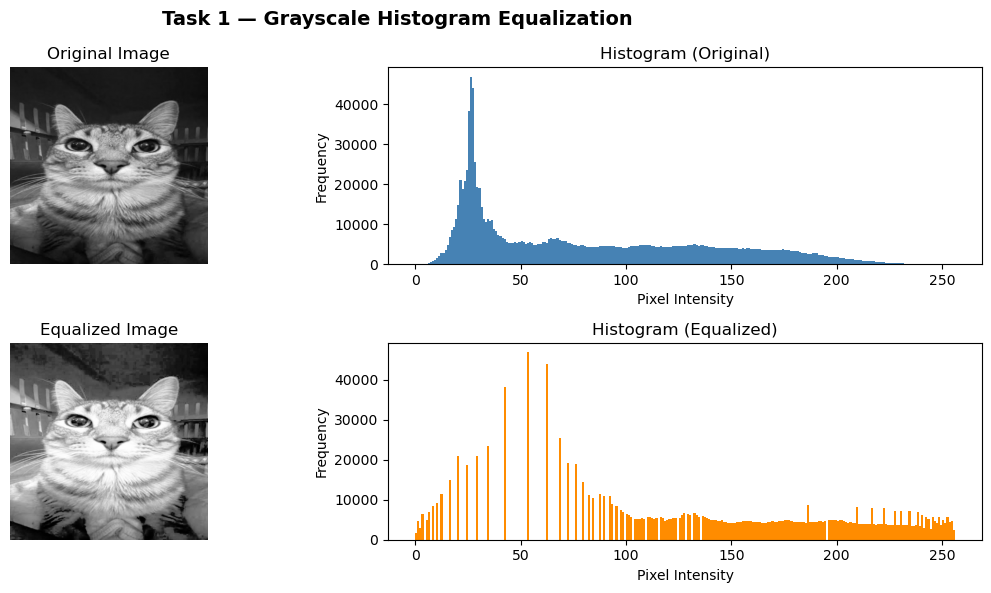

In [2]:
# Task 1 
image = cv2.imread('newcat.png', cv2.IMREAD_GRAYSCALE)

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), 256, [0, 256], color='steelblue')
plt.title('Histogram (Original)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(equalized_image.ravel(), 256, [0, 256], color='darkorange')
plt.title('Histogram (Equalized)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.suptitle('Task 1 — Grayscale Histogram Equalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 2: Histogram Equalization on Color Images

/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/854629676.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(orig_ch.ravel(), 256, [0, 256], alpha=0.5, label='Original', color=col)
/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/854629676.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(eq_ch.ravel(),   256, [0, 256], alpha=0.5, label='Equalized', color='gray')


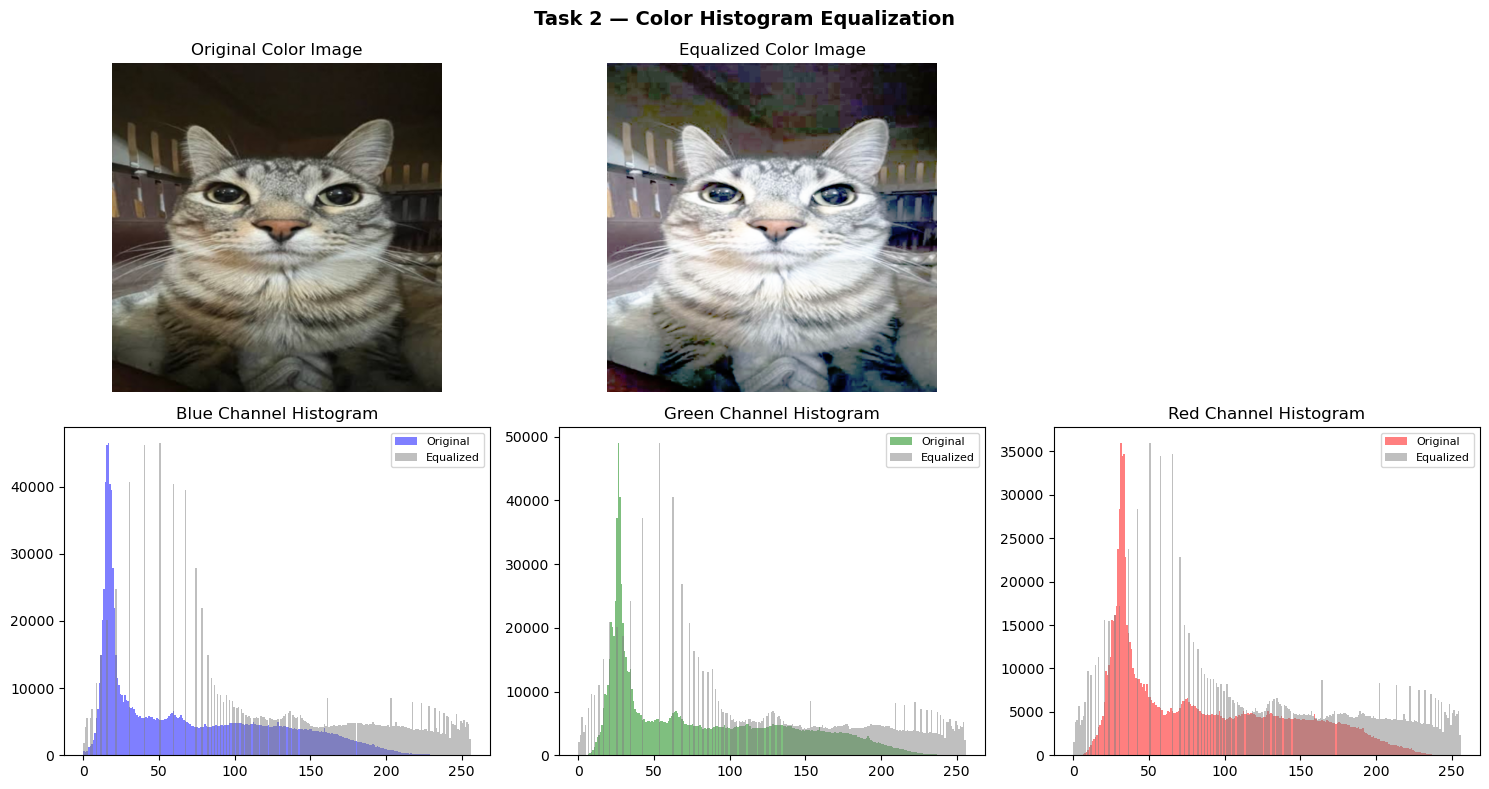

In [10]:
# Task 2
color_image = cv2.imread('newcat.png')

(b, g, r) = cv2.split(color_image)

equalized_b = cv2.equalizeHist(b)
equalized_g = cv2.equalizeHist(g)
equalized_r = cv2.equalizeHist(r)

equalized_color_image = cv2.merge([equalized_b, equalized_g, equalized_r])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Color Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Equalized Color Image')
axes[0, 1].axis('off')

colors = [('Blue', b, equalized_b, 'blue'),
          ('Green', g, equalized_g, 'green'),
          ('Red',   r, equalized_r, 'red')]

for idx, (name, orig_ch, eq_ch, col) in enumerate(colors):
    ax = axes[1, idx]
    ax.hist(orig_ch.ravel(), 256, [0, 256], alpha=0.5, label='Original', color=col)
    ax.hist(eq_ch.ravel(),   256, [0, 256], alpha=0.5, label='Equalized', color='gray')
    ax.set_title(f'{name} Channel Histogram')
    ax.legend(fontsize=8)

axes[0, 2].axis('off') 

plt.suptitle('Task 2 — Color Histogram Equalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 3: Histogram Matching (Specification)

/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/3831204365.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0, 256], color=hist_colors[i])


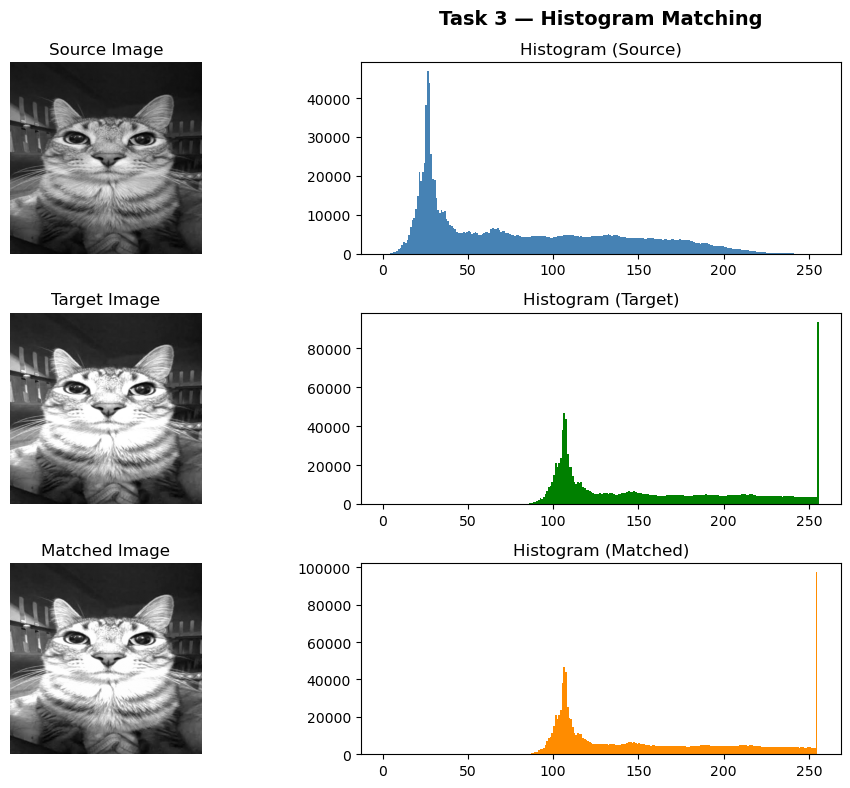

In [5]:
# Task 3
image_source = cv2.imread('newcat.png', cv2.IMREAD_GRAYSCALE)

image_target = np.clip(image_source.astype(np.int32) + 80, 0, 255).astype(np.uint8)

matched_image = exposure.match_histograms(image_source, image_target)
matched_image = matched_image.astype(np.uint8)

plt.figure(figsize=(15, 8))

titles = ['Source Image', 'Histogram (Source)',
          'Target Image', 'Histogram (Target)',
          'Matched Image', 'Histogram (Matched)']
images = [image_source, None, image_target, None, matched_image, None]
hists  = [None, image_source, None, image_target, None, matched_image]
hist_colors = ['steelblue', 'green', 'darkorange']

positions = [1, 2, 4, 5, 7, 8]
img_list  = [image_source, image_target, matched_image]

for i, (img, pos) in enumerate(zip(img_list, [1, 4, 7])):
    plt.subplot(3, 3, pos)
    plt.imshow(img, cmap='gray')
    plt.title(['Source Image', 'Target Image', 'Matched Image'][i])
    plt.axis('off')

    plt.subplot(3, 3, pos + 1)
    plt.hist(img.ravel(), 256, [0, 256], color=hist_colors[i])
    plt.title(['Histogram (Source)', 'Histogram (Target)', 'Histogram (Matched)'][i])

plt.suptitle('Task 3 — Histogram Matching', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 4: Combining Histogram Equalization and Matching


/var/folders/jw/b7tqgv190dg8t0dcvb2jcrb80000gn/T/ipykernel_5111/1346822067.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, i].hist(img.ravel(), 256, [0, 256], color=col)


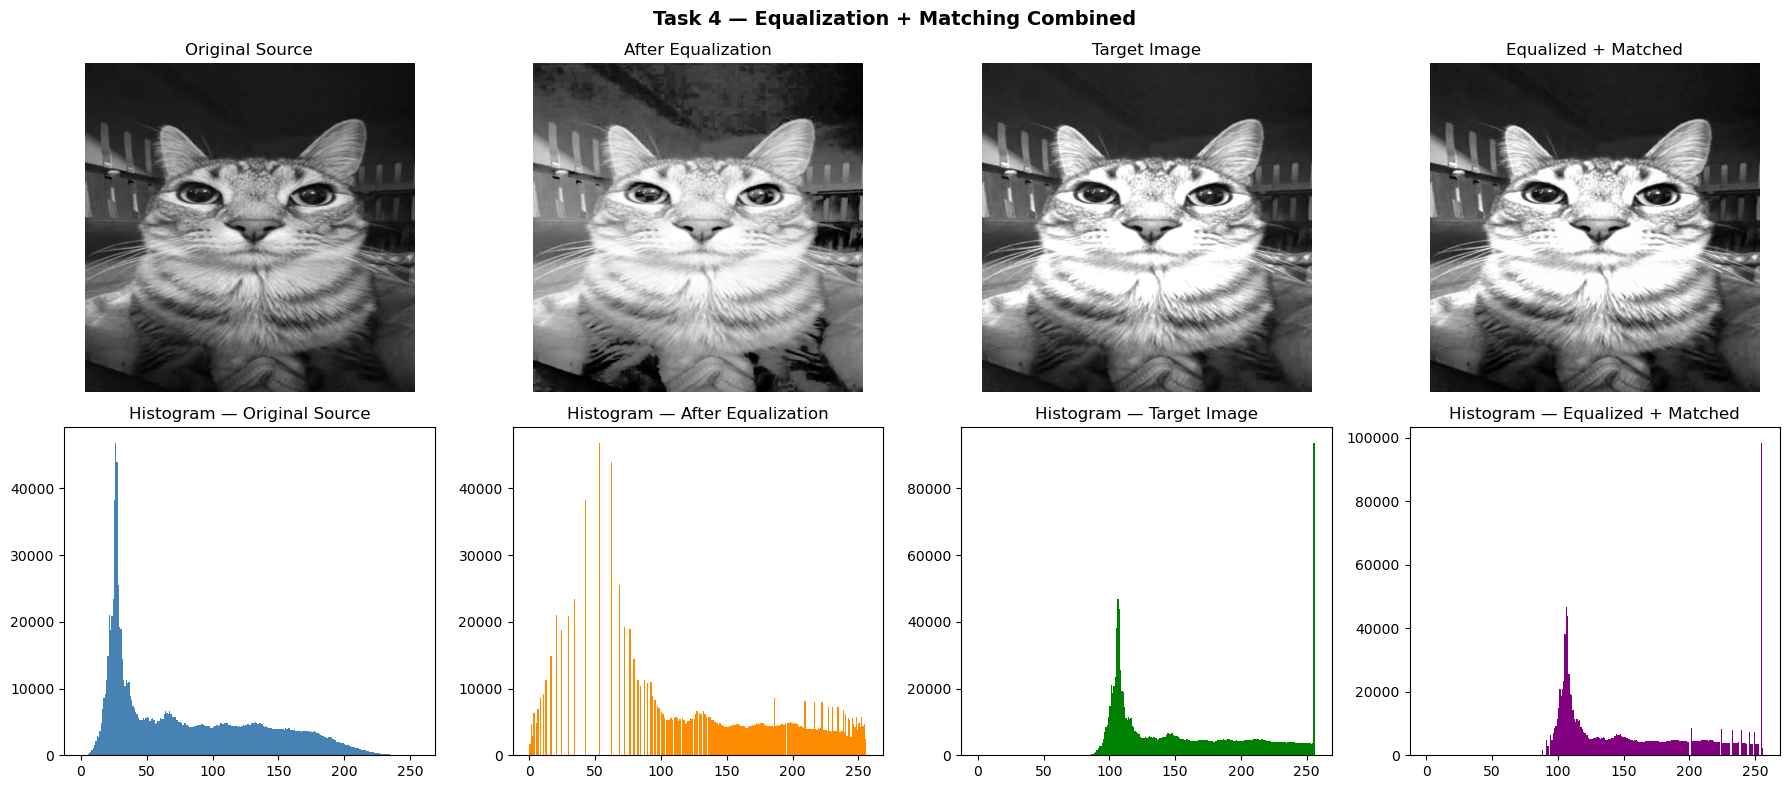

In [8]:
# Task 4
source = cv2.imread('newcat.png', cv2.IMREAD_GRAYSCALE)
target = np.clip(source.astype(np.int32) + 80, 0, 255).astype(np.uint8)  # synthetic target

# Step 1: Equalize the source
equalized = cv2.equalizeHist(source)

# Step 2: Match equalized image to target
eq_matched = exposure.match_histograms(equalized, target).astype(np.uint8)

# Display all four stages
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

stage_imgs = [source, equalized, target, eq_matched]
stage_names = ['Original Source', 'After Equalization', 'Target Image', 'Equalized + Matched']
stage_cols = ['steelblue', 'darkorange', 'green', 'purple']

for i, (img, name, col) in enumerate(zip(stage_imgs, stage_names, stage_cols)):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(name)
    axes[0, i].axis('off')

    axes[1, i].hist(img.ravel(), 256, [0, 256], color=col)
    axes[1, i].set_title(f'Histogram — {name}')

plt.suptitle('Task 4 — Equalization + Matching Combined', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Lab Report

### Summary of Results

**Task 1 — Grayscale Histogram Equalization**  
Histogram equalization redistributes the pixel intensity values across the full 0–255 range using the Cumulative Distribution Function (CDF). In the original image the histogram was concentrated in a narrow band (most pixels clustered around mid-dark values), resulting in low contrast. After equalization the histogram spread out more uniformly, significantly improving contrast and making details in both dark and bright regions more visible. This technique is especially effective for images taken in poor lighting because it amplifies small differences in intensity that were previously invisible.

**Task 2 — Color Histogram Equalization (Per-Channel)**  
Applying cv2.equalizeHist() independently to the R, G, and B channels enhanced the overall brightness and contrast of the color image. However, since each channel is equalized separately without regard to the others, the relative color balance can shift — some colors become oversaturated or take on unnatural hues. A better approach for color images is to convert to a color space like HSV or YCrCb and equalize only the luminance channel, preserving natural colors while still improving contrast.

**Task 3 — Histogram Matching (Specification)**  
exposure.match_histograms() from scikit-image maps the pixel intensities of the source image to match the cumulative distribution of the target image. The source image visually adopted the brightness and contrast style of the target — darker images become brighter when matched to a bright target, and vice versa. The technique is useful in applications such as photo editing, medical imaging, and satellite image processing where consistent appearance across images is required.

**Task 4 — Combined Equalization + Matching**  
First equalizing the source spreads intensities uniformly (flat histogram). Then applying histogram matching maps this equalized distribution onto the target's distribution. The result is an image that simultaneously has improved internal contrast (from equalization) and the overall brightness/tone profile of the target (from matching). Compared to matching alone, the combined approach provides richer detail in shadows and highlights while still conforming to the target's tonal range.